In [1]:
from pathlib import Path
from lexos.dtm import DTM
from lexos.cluster.kmeans import KMeansCluster

In [2]:
base_dir = Path.cwd().parent / "FilesToUse"
file_paths = sorted(base_dir.glob("*.txt"))

docs = []
labels = []

for path in file_paths:
    with open(path, "r", encoding="utf-8") as f:
        docs.append(f.read().split())
        labels.append(path.stem)

print(f"Loaded {len(docs)} documents:", labels)

Loaded 8 documents: ['AI_The_Hermit', 'AI_The_Invention', 'HenryWP_ThePirate', 'HenryWP_ThePirate_Short', 'Irving_RipVanWInkle', 'Lippard_BelOfPrairieEden', 'Melville_MobyDick', 'Poe_FallOfHouseUsher_1839']


In [3]:
dtm = DTM()
dtm(docs, labels)

In [4]:
kmeans = KMeansCluster()
kmeans.dtm = dtm

Running elbow plot for k = 1 to 8 (limited to document count)


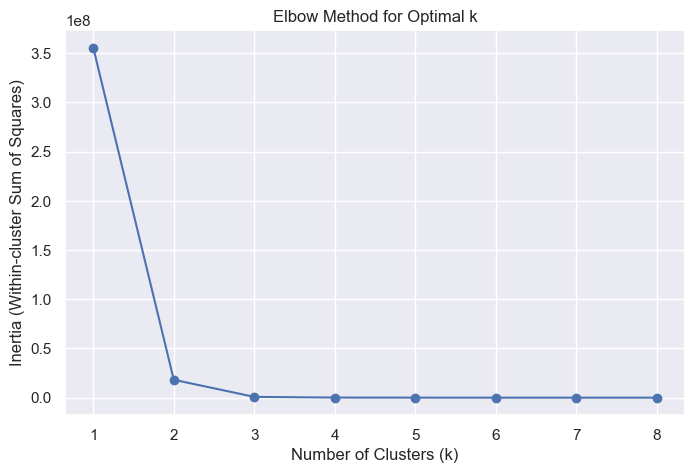

In [5]:
kmeans.elbow_plot(k_range=range(1, 10))

In [6]:
kmeans(k=2)

array([0, 0, 0, 0, 0, 0, 1, 0], dtype=int32)

In [7]:
kmeans.plot_2d(show=True)

In [8]:
kmeans.plot_3d(show=True)

In [9]:
# Ensure the required packages are installed
%pip install plotly

import plotly.io as pio
print("Plotly kaleido scope:", pio.kaleido.scope)


Note: you may need to restart the kernel to use updated packages.
Plotly kaleido scope: <plotly.io._kaleido.DefaultsWrapper object at 0x178ec6870>


In [10]:
kmeans.plot_2d(show=True)
kmeans.save_png("clusters.png")
kmeans.save_svg("clusters.svg")


In [11]:
kmeans.export_csv("clusters.csv")

In [ ]:
kmeans.plot_voronoi(show=True)